<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Semanal N°7

Autor: *Olea Gasalla Ignacio Ezequiel*

*Fecha de entrega: jueves 17 de septiembre de 2026*

#### **Consigna** 
<img src="./consigna_1.png" /> 
<img src="./consigna_2.png" /> 

##### **Bonus**:
<img src="./consigna_bonus.png" /> 

##### **Anexo**:
📎 En caso de no poder acceder al documento, presione aquí: [Mostrar PDF](./tc2_ts7.pdf)

In [151]:
from IPython.display import IFrame
IFrame("./tc2_ts7.pdf", width=1000, height=1000)

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import diff

def analizar_Hz(Hs, n_points=2000):

    # =========================================================
    # FRECUENCIA
    # =========================================================

    Omega = np.linspace(0, np.pi, n_points)

    # Circunferencia unidad: z = e^(jΩ)
    z = np.exp(1j * Omega)

    # =========================================================
    # FIGURA
    # =========================================================

    fig, axs = plt.subplots(1, 3, figsize=(17, 5))

    # =========================================================
    # GUARDAMOS POLOS Y CEROS PARA EL DIAGRAMA
    # =========================================================

    todos_ceros = []
    todos_polos = []

    # =========================================================
    # PROCESAMOS CADA H(z)
    # =========================================================

    for H in Hs:

        k = H["k"]
        num = np.asarray(H["num"], dtype=float)
        den = np.asarray(H["den"], dtype=float)
        label = H.get("label", "H(z)")

        # -----------------------------------------------------
        # Polos y ceros
        # -----------------------------------------------------

        ceros = np.roots(num)
        polos = np.roots(den)

        todos_ceros.append(ceros)
        todos_polos.append(polos)

        print("\n" + "=" * 50)
        print(label)

        print("\nCeros:")

        for cero in ceros:
            print(f"  {cero.real:.5f} {cero.imag:+.5f}j")

        print("\nPolos:")

        for polo in polos:
            print(f"  {polo.real:.5f} {polo.imag:+.5f}j")

        # -----------------------------------------------------
        # Evaluamos H(e^jΩ)
        # -----------------------------------------------------

        Num = np.polyval(num, z)
        Den = np.polyval(den, z)

        H_z = k * Num / Den

        modulo = np.abs(H_z)

        # np.angle devuelve la fase entre -π y π
        fase = np.unwrap(np.angle(H_z))

        # -----------------------------------------------------
        # MÓDULO
        # -----------------------------------------------------

        axs[0].plot(
            Omega,
            modulo,
            label=label
        )

        # -----------------------------------------------------
        # FASE
        # -----------------------------------------------------

        axs[1].plot(
            Omega,
            fase,
            label=label
        )

    # =========================================================
    # MÓDULO
    # =========================================================

    axs[0].set_title(r"Módulo $|H(e^{j\Omega})|$")
    axs[0].set_xlabel(r"$\Omega$ [rad/muestra]")
    axs[0].set_ylabel(r"$|H|$")

    axs[0].set_xlim(0, np.pi)

    axs[0].set_xticks(
        [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
        [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
    )

    axs[0].grid(True)
    axs[0].legend()

    # =========================================================
    # FASE
    # =========================================================

    axs[1].set_title(r"Fase $\angle H(e^{j\Omega})$")
    axs[1].set_xlabel(r"$\Omega$ [rad/muestra]")
    axs[1].set_ylabel("Fase [rad]")

    axs[1].set_xlim(0, np.pi)

    axs[1].set_xticks(
        [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi],
        [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
    )

    axs[1].grid(True)
    axs[1].legend()

    # =========================================================
    # DIAGRAMA POLOS Y CEROS
    # =========================================================

    theta = np.linspace(0, 2*np.pi, 500)

    # Circunferencia unidad
    axs[2].plot(
        np.cos(theta),
        np.sin(theta),
        '--',
        linewidth=1,
        label=r"$|z|=1$"
    )

    # Ejes
    axs[2].axhline(0, linewidth=0.8)
    axs[2].axvline(0, linewidth=0.8)

    # ---------------------------------------------------------
    # Ceros
    # ---------------------------------------------------------

    for ceros, H in zip(todos_ceros, Hs):
    
        label = H.get("label", r"$H(z)$")
    
        axs[2].plot(
            ceros.real,
            ceros.imag,
            'o',
            markersize=20,
            markerfacecolor='none',
            label=f"Ceros {label}"
        )

    # ---------------------------------------------------------
    # Polos
    # ---------------------------------------------------------

    for polos, H in zip(todos_polos, Hs):

        label = H.get("label", r"$H(z)$")

        axs[2].plot(
            polos.real,
            polos.imag,
            'x',
            markersize=17,
            markeredgewidth=2,
            label=f"Polos {label}",
            color = 'black'
        )

    # ---------------------------------------------------------
    # Configuración
    # ---------------------------------------------------------

    axs[2].set_title("Diagrama de polos y ceros")

    axs[2].set_xlabel(r"$\operatorname{Re}\{z\}$")
    axs[2].set_ylabel(r"$\operatorname{Im}\{z\}$")

    axs[2].grid(True)
    axs[2].axis("equal")
    axs[2].legend(fontsize=8 , loc='upper right')

    # =========================================================
    # MOSTRAR
    # =========================================================

    plt.tight_layout()
    plt.show()
  

#### Moving Average

 En el siguiente bloque de código se gráfico las funciones transferencia resultantes del filtro de media movil de orden $N=3 , N=4 , N=5$ junto con su diagrama de polos y ceros.
 Los polos pertenecientes a las 3 transferencias caen en el $Z=0+j0$, siendo que, aunque no estén perfectamente representados, en $N=3$ se tiene un polo doble en el origen; en $N=4$, un polo triple; y en $N=5$, un polo cuadruple.

 La función utilizada para el gráfico fue obtenida por agentes externos y se recomienda su uso a discreción.
 Permite graficar el módulo y la fase respecto a $\Omega$ y el diagrama de polos y ceros de una transferencia discreta de la forma $H(Z)$ e indica la posición de sus polos y ceros.
 Creando un array de bloques de transferencias (llamado en el código como "Hn") se pueden obtener los gráficos de las curvas en la misma figura de forma conveniente.


H_3(Z):

Ceros:
  -0.50000 +0.86603j
  -0.50000 -0.86603j

Polos:
  0.00000 +0.00000j
  0.00000 +0.00000j

H_4(Z):

Ceros:
  -1.00000 +0.00000j
  -0.00000 +1.00000j
  -0.00000 -1.00000j

Polos:
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j

H_5(Z):

Ceros:
  0.30902 +0.95106j
  0.30902 -0.95106j
  -0.80902 +0.58779j
  -0.80902 -0.58779j

Polos:
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j


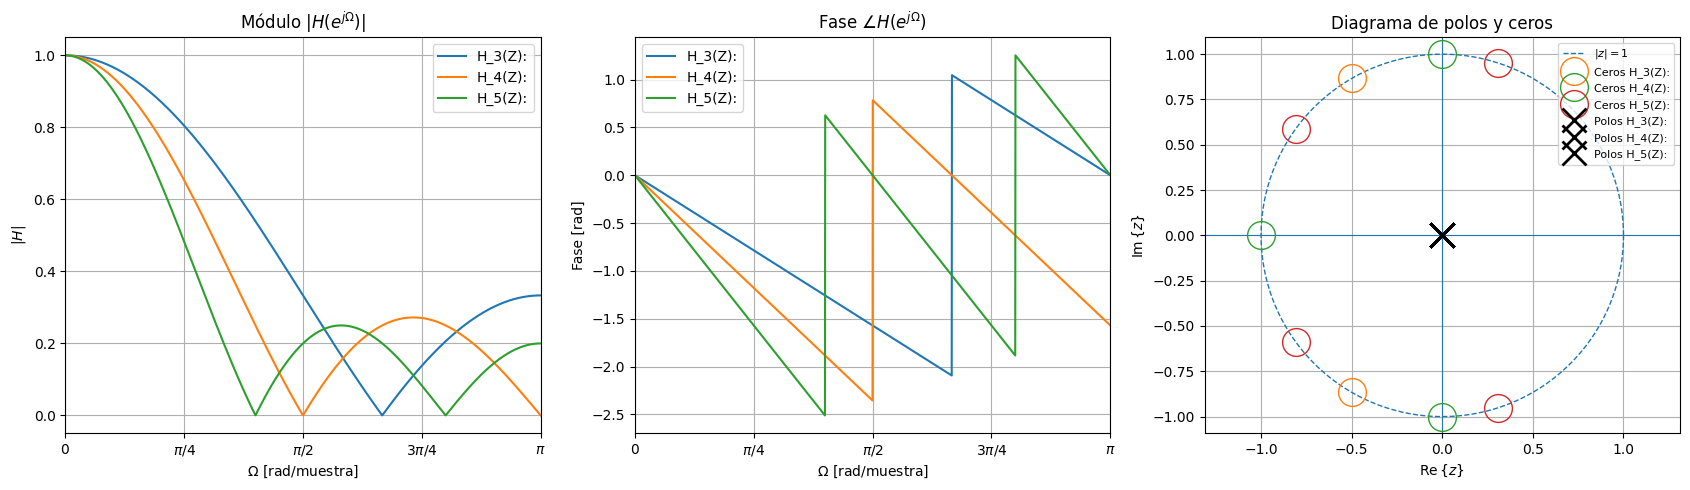

In [153]:
Hn = [
    {
        "k": 1/3,
        "num": [1, 1, 1],
        "den": [1, 0, 0],
        "label": r"H_3(Z):"
    },
    {
        "k": 1/4,
        "num": [1, 1, 1, 1],
        "den": [1, 0, 0, 0],
        "label": r"H_4(Z):"
    },
    {
        "k": 1/5,
        "num": [1, 1, 1, 1, 1],
        "den": [1, 0, 0, 0, 0],
        "label": r"H_5(Z):"
    }
]

analizar_Hz(Hn)  


#### Differentiator

 Como se muestra en el siguiente bloque de código, se logró derivar un seno discreto con la transferencia del **differentiator** que tiene la misma forma que la derivada del seno temporal. 
 Se logró comparar el resultado del diferenciador con la derivada temporal y con la respuesta de la función "diff()" de Scipy con buenos resultados.

 Además, en el segundo bloque de código se graficó la respuesta del diferenciador.

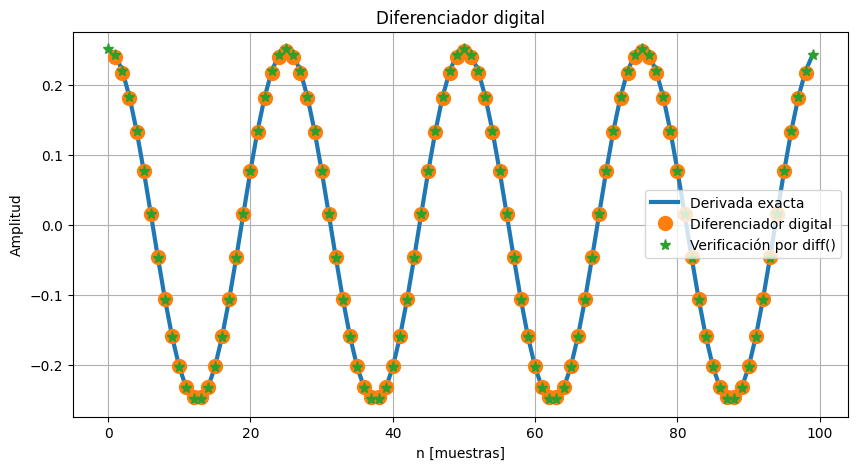

In [154]:
# Parámetros
W = 2*np.pi * 20
Fs = 500
Ts = 1/Fs
N = 100

# Creo un array con N numeros sucesivos: [0,1,2,3,4,5,...]
n = np.arange(N)

# Guardo la señal de entrada discretizada y creo la salida como un array de N elementos vacios
x = np.sin( W*Ts * n ) # sen(wt) -> sen(wTs n)
y = np.zeros(N-2)

# Diferenciador digital
y = (x[2:] - x[:-2]) / 2

# x[]   = [0,1,2,3,4,5,6,7,8,9]
# x[2:] = [2,3,4,5,6,7,8,9]
# x[:2] = [0,1,2,3,4,5,6,7]

# Derivada exacta
dy = W*Ts * np.cos( W*Ts * n ) # wt' cos(wt) -> wTs cos(wTs n)

# Verificación por diff()
dfy = diff(x , period= N )

# -----------------------------
# Gráfico
# -----------------------------

plt.figure(figsize=(10,5))

# Derivada exacta como curva continua
plt.plot(n, dy, linewidth=3 ,label="Derivada exacta")

# Salida del diferenciador como puntos
plt.plot(n[1:-1], y, 'o', markersize=10, label="Diferenciador digital")

# Derivada mediante FFT
plt.plot(n, dfy, '*', markersize=8, label="Verificación por diff()")

plt.xlabel("n [muestras]")
plt.ylabel("Amplitud")
plt.title("Diferenciador digital")
plt.grid()
plt.legend()

plt.show()



H(Z):

Ceros:
  -1.00000 +0.00000j
  1.00000 +0.00000j

Polos:
  0.00000 +0.00000j
  0.00000 +0.00000j


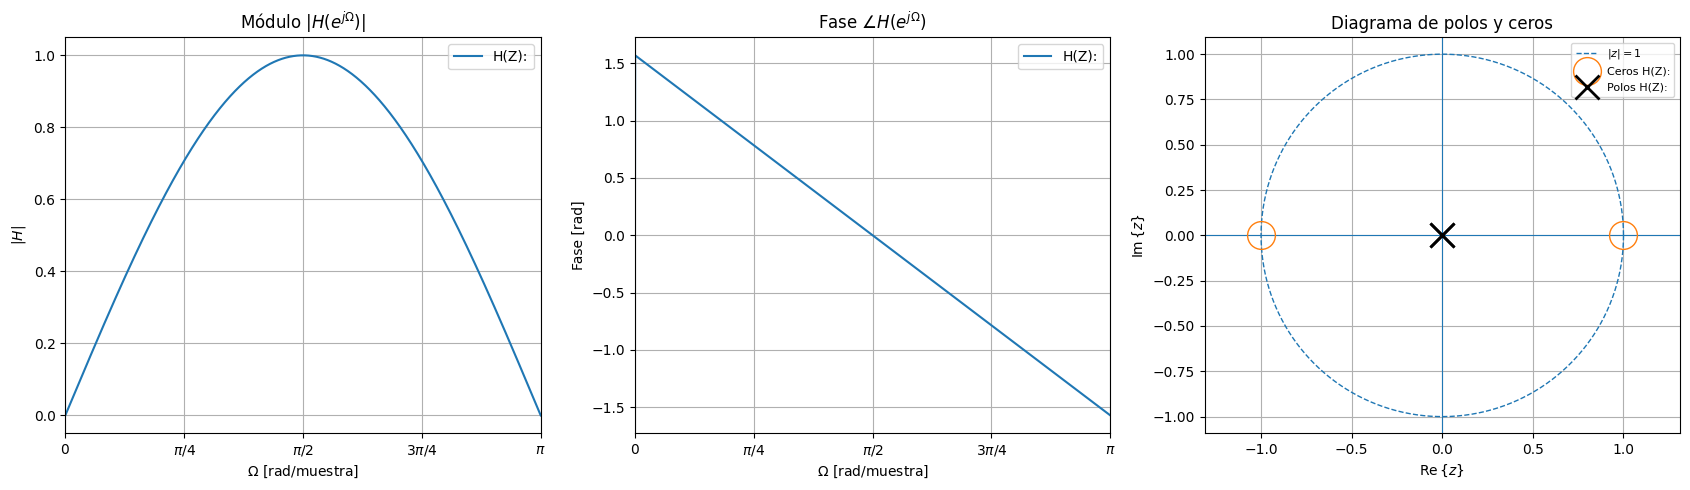

In [155]:
Hn = [
    {
        "k": 1/2,
        "num": [1, 0, -1],
        "den": [1, 0, 0],
        "label": r"H(Z):"
    }
]

analizar_Hz(Hn)  


#### DC Blocker

 Se verifica la funcionalidad del DC blocker (ya que en $\Omega=0$ la transferencia es nula) y se halló que para un $\beta=0.7271$ se consigue que caiga $-3dB = 0.707 veces$ la transferencia en $\Omega=\pi$ para $H(\Omega=\frac{\pi}{10})$.


H_b1(Z):

Ceros:
  1.00000 +0.00000j

Polos:
  0.90000 +0.00000j


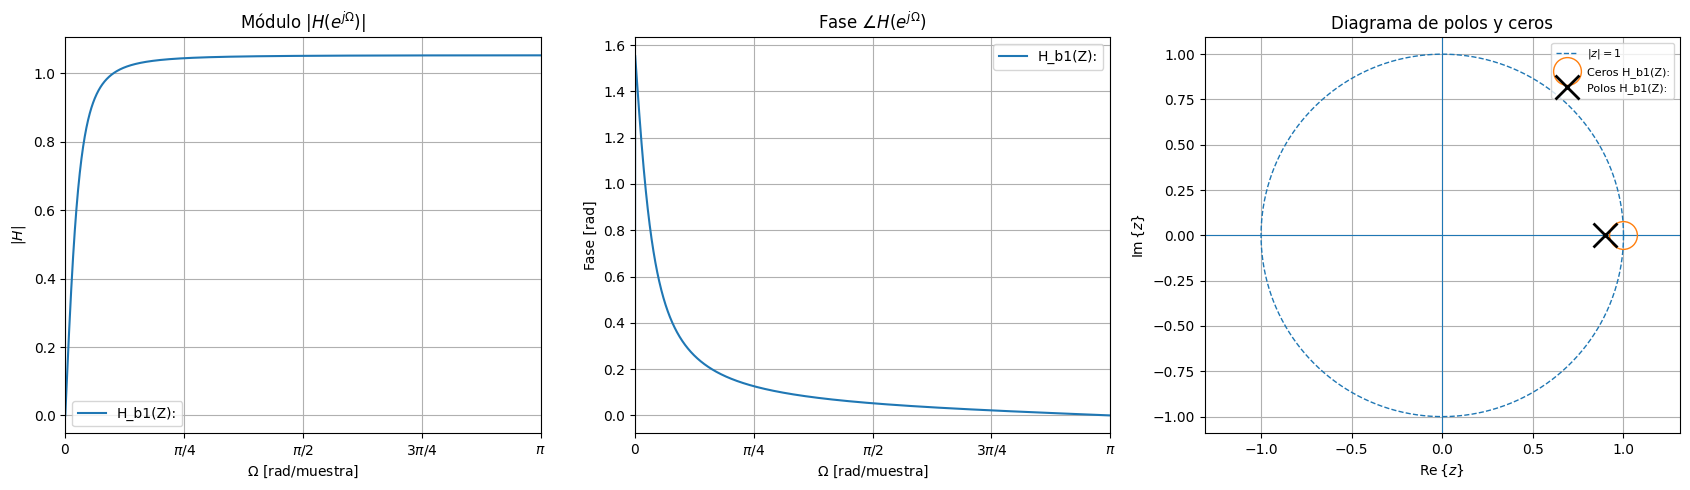

Beta =  0.9

H_b2(Z):

Ceros:
  1.00000 +0.00000j

Polos:
  0.72710 +0.00000j


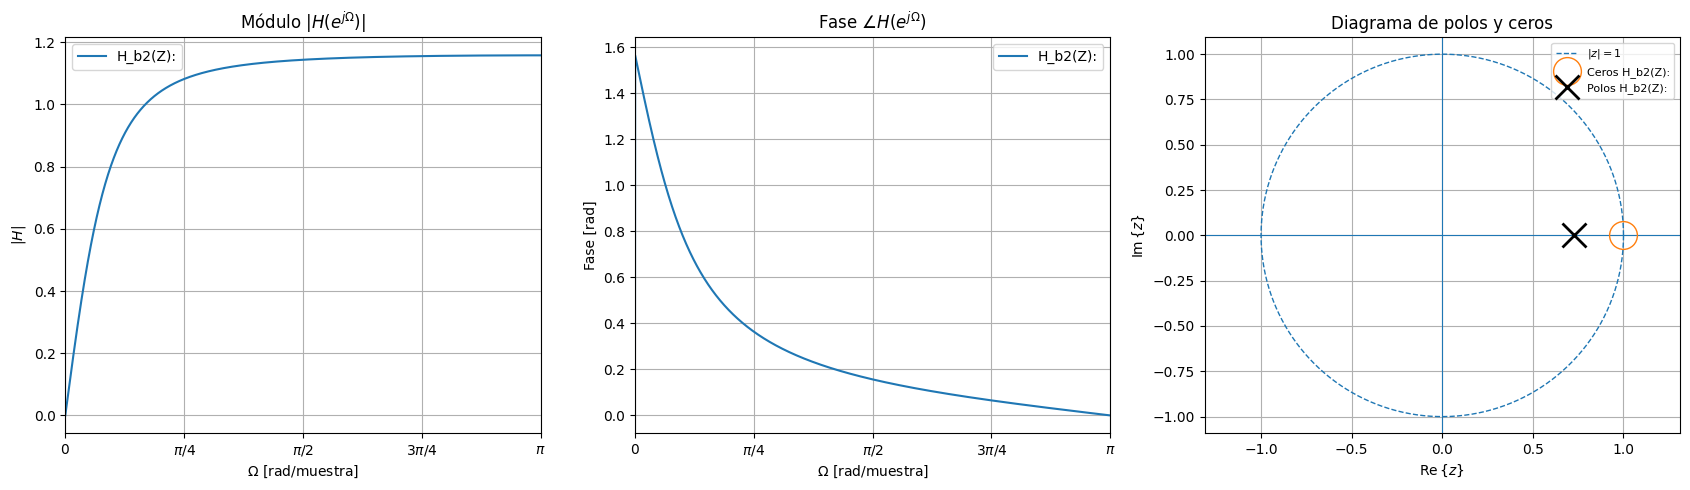

Beta =  0.7271


In [156]:
b1 = 0.9
b2 = 0.7271

H_b1 = [
    {
        "k": 1,
        "num": [1, -1],
        "den": [1, -b1],
        "label": r"H_b1(Z):"
    }
]

H_b2 = [
    {
        "k": 1,
        "num": [1, -1],
        "den": [1, -b2],
        "label": r"H_b2(Z):"
    }
]


analizar_Hz(H_b1) 
print(r"Beta = ",b1)

analizar_Hz(H_b2)  
print(r"Beta = ",b2)


#### Comb Filter

 En el proximo bloque de código se analiza el **comb filter**, primero se grafica (módulo, fase y polos y ceros) respecto a $\Omega$ y luego se elige se forma arbitraria una frecuencia de muestreo.
 Se eligió $f_{sampling}=80Hz$ de forma que los "nulls" y los "peaks" ocurran en multiplos de 5Hz tal como se muestra en el documento adjunto.


H(Z):

Ceros:
  -0.92388 +0.38268j
  -0.92388 -0.38268j
  -0.38268 +0.92388j
  -0.38268 -0.92388j
  0.38268 +0.92388j
  0.38268 -0.92388j
  0.92388 +0.38268j
  0.92388 -0.38268j

Polos:
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j
  0.00000 +0.00000j


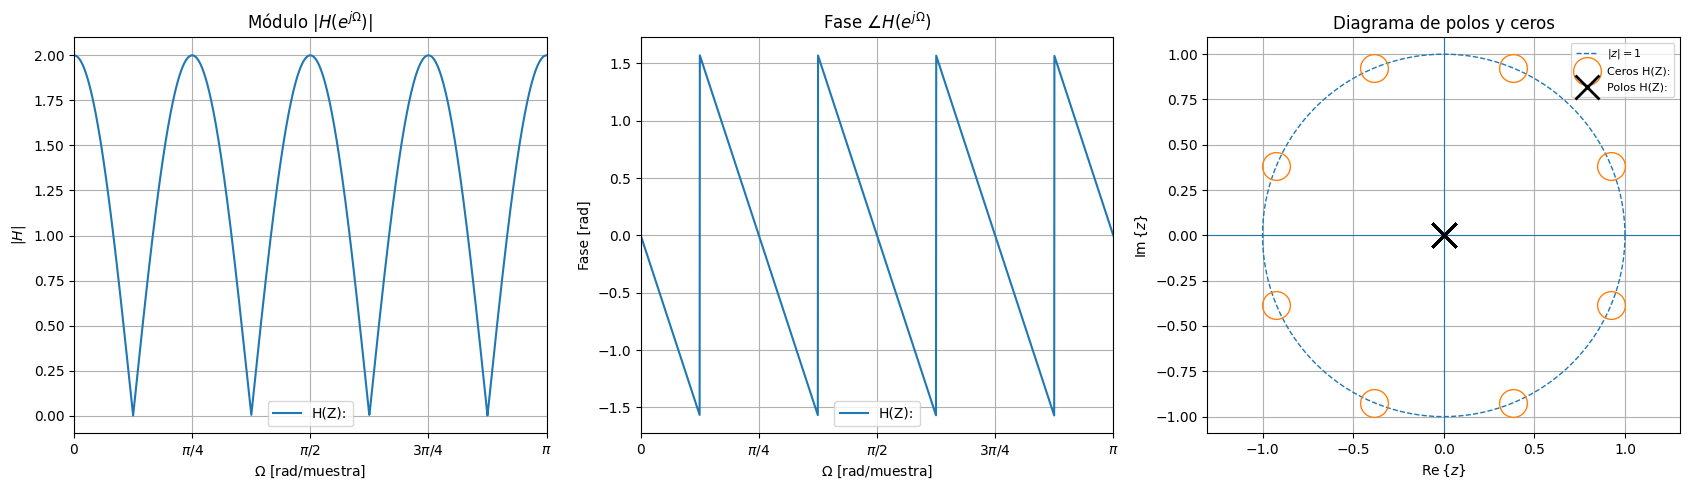


Gráfico del módulo de la transferencia del Comb Filter con una frecuencia de muestreo de 80 Hz:



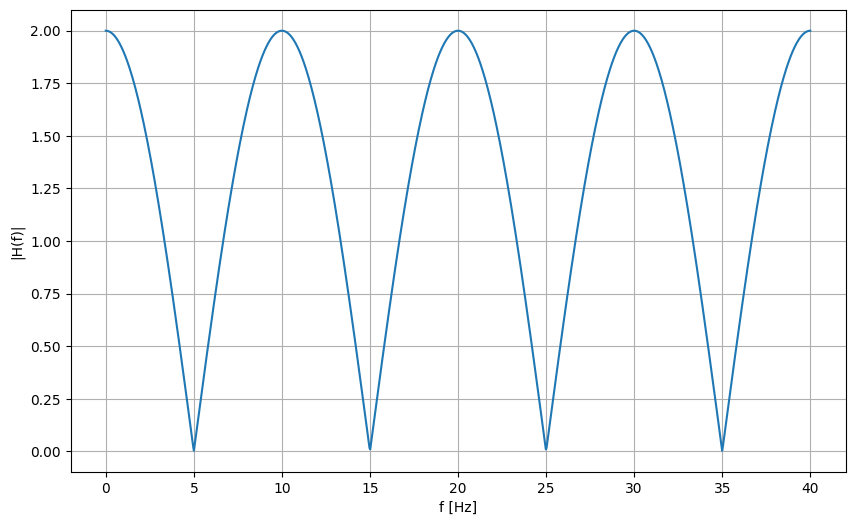

In [157]:
Hn = [
    {
        "k": 1,
        "num": [1, 0, 0, 0, 0, 0, 0, 0, 1],
        "den": [1, 0, 0, 0, 0, 0, 0, 0, 0],
        "label": r"H(Z):"
    }
]

analizar_Hz(Hn) 

# ==========================================
f_sampling = 80 # Hz
f = np.linspace(0, 40, 1000) # de 0Hz a 40Hz

Omega = 2*np.pi * f / f_sampling 

H_abs = 2* np.abs( np.cos( 4 * Omega ) )

print('\n==================================================')
print(r"Gráfico del módulo de la transferencia del Comb Filter con una frecuencia de muestreo de", f_sampling, "Hz:\n")
plt.figure(figsize=(10, 6))
plt.plot( f , H_abs )
plt.xlabel("f [Hz]")
plt.ylabel("|H(f)|")
plt.grid()
plt.show()